In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

In [4]:
metadata = pd.read_csv("data/processed/metadata_with_moa.csv")
metadata.head(3)

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors


Treating Missing Data

In [5]:
def image_exists(row):
    paths = [
        os.path.join(BASE_DIR, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"]),
        os.path.join(BASE_DIR, row["Image_PathName_Tubulin"], row["Image_FileName_Tubulin"]),
        os.path.join(BASE_DIR, row["Image_PathName_Actin"], row["Image_FileName_Actin"])
    ]

    return all(os.path.exists(p) for p in paths)

In [6]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/data/raw"
metadata_with_moa = metadata[metadata.apply(image_exists, axis=1)].reset_index(drop=True)

print("Original rows:", len(metadata))
print("Valid rows:", len(metadata_with_moa))
print("Removed rows:", len(metadata) - len(metadata_with_moa))

Original rows: 3848
Valid rows: 3848
Removed rows: 0


Step 1: Load & stack channels - Merging channels for faster traianing time

In [7]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.transform import resize
from tqdm import tqdm

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/data/raw"


def load_triplet_from_metadata(row):
    dapi_path = os.path.join(BASE_DIR, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"]),
    tubulin_path = os.path.join(BASE_DIR, row["Image_PathName_Tubulin"], row["Image_FileName_Tubulin"])
    actin_path = os.path.join(BASE_DIR, row["Image_PathName_Actin"], row["Image_FileName_Actin"])

    dapi = tiff.imread(dapi_path)
    tubulin = tiff.imread(tubulin_path)
    actin = tiff.imread(actin_path)

    return np.stack([dapi, tubulin, actin], axis=0)  # (3, H, W)

In [8]:
row = metadata_with_moa.iloc[0]
img = load_triplet_from_metadata(row)

print(img.shape)  # should be (3, 1024, 1280)

(3, 1024, 1280)


In [9]:
print("Shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())

Shape: (3, 1024, 1280)
Min: 208
Max: 55600


6 Intensity Clipping

In [10]:
def clip_intensity(img):

    clipped = np.zeros_like(img)

    for c in range(img.shape[0]):

        low = np.percentile(img[c], 0.01)
        high = np.percentile(img[c], 99.9)

        clipped[c] = np.clip(img[c], low, high)

    return clipped

In [11]:
img_clipped = clip_intensity(img)

print("Before max:", img.max())
print("After max:", img_clipped.max())

Before max: 55600
After max: 34452


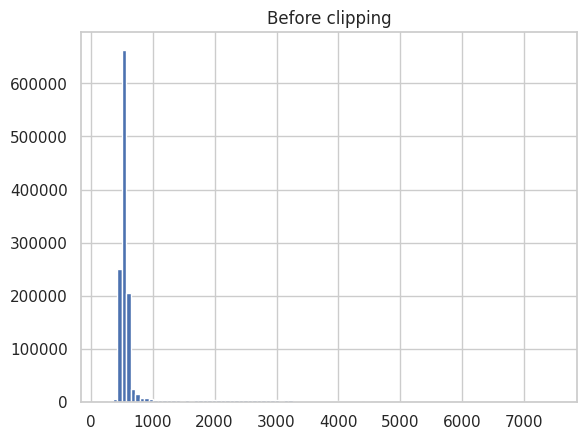

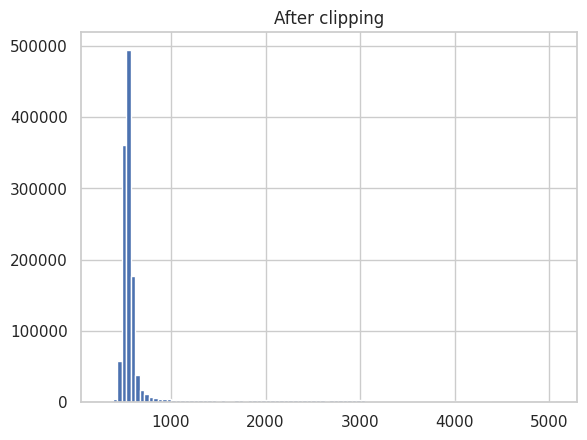

In [12]:
plt.hist(img[0].flatten(), bins=100)
plt.title("Before clipping")
plt.show()

plt.hist(img_clipped[0].flatten(), bins=100)
plt.title("After clipping")
plt.show()

In [13]:
print("Clipped min:", img_clipped.min())
print("Clipped max:", img_clipped.max())

for c in range(3):
    print(f"Channel {c} min:", img_clipped[c].min())
    print(f"Channel {c} max:", img_clipped[c].max())

Clipped min: 288
Clipped max: 34452
Channel 0 min: 288
Channel 0 max: 5056
Channel 1 min: 832
Channel 1 max: 34452
Channel 2 min: 368
Channel 2 max: 16656


7 Scale Intensities to [0,1]

In [14]:
def scale_to_unit(img):

    scaled = np.zeros(img.shape, dtype=np.float32)

    for c in range(img.shape[0]):

        min_val = img[c].min()
        max_val = img[c].max()

        scaled[c] = (img[c] - min_val) / (max_val - min_val + 1e-8)

    return scaled

In [15]:
img_scaled = scale_to_unit(img_clipped)

print("Scaled min:", img_scaled.min())
print("Scaled max:", img_scaled.max())
print("dtype:", img_scaled.dtype)

Scaled min: 0.0
Scaled max: 1.0
dtype: float32


8 Compute Otsu DNA mask

In [16]:
def compute_dna_mask(img_scaled):

    dna = img_scaled[0]

    thresh = threshold_otsu(dna)

    mask = dna > thresh

    return mask, thresh

Otsu threshold: 0.29882812


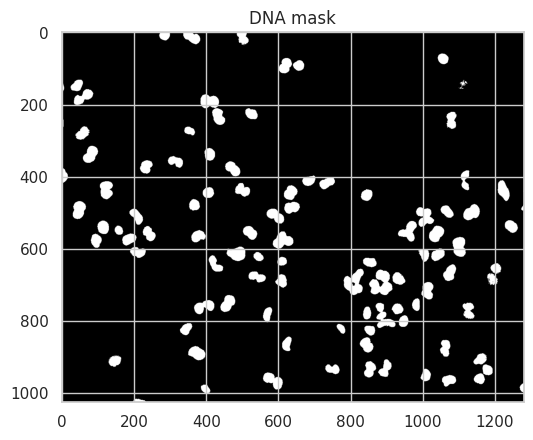

In [17]:
mask, thresh = compute_dna_mask(img_scaled)

print("Otsu threshold:", thresh)

plt.imshow(mask, cmap="gray")
plt.title("DNA mask")
plt.show()

white regions = nuclei

9 Random crop sampler (224×224)

In [18]:
def random_crop(img, mask, crop_size=224):

    C, H, W = img.shape

    y = np.random.randint(0, H - crop_size)
    x = np.random.randint(0, W - crop_size)

    crop_img = img[:, y:y+crop_size, x:x+crop_size]
    crop_mask = mask[y:y+crop_size, x:x+crop_size]

    return crop_img, crop_mask

10 Keep crops with cells (>=1% DNA)

In [19]:
def sample_valid_crop(img_scaled, mask, crop_size=224):

    for _ in range(50):

        crop_img, crop_mask = random_crop(img_scaled, mask, crop_size)

        dna_fraction = crop_mask.mean()

        if dna_fraction >= 0.01:
            return crop_img

    return None

In [20]:
crop = sample_valid_crop(img_scaled, mask)

print("Crop shape:", crop.shape)

Crop shape: (3, 224, 224)


11 Visualize crop

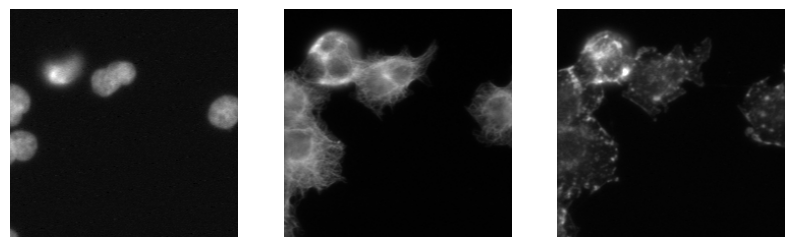

In [21]:
fig, axes = plt.subplots(1,3, figsize=(10,4))

for i in range(3):
    axes[i].imshow(crop[i], cmap="gray")
    axes[i].axis("off")

plt.show()

12 Resize to training resolution

In [22]:
def resize_for_model(img):

    img_small = resize(img, (3,128,128), anti_aliasing=True)

    return img_small

13 Full preprocessing pipeline

In [23]:
def preprocess_image(row):

    img = load_triplet_from_metadata(row)

    img = clip_intensity(img)

    img = scale_to_unit(img)

    mask, _ = compute_dna_mask(img)

    crop = sample_valid_crop(img, mask)

    # If no correct crop is found
    if crop is None:
        return None

    crop = resize(crop, (3,128,128), anti_aliasing=True)

    return crop

14 Full Sanity Check

In [24]:
sample = preprocess_image(metadata_with_moa.iloc[0])

print("Final shape:", sample.shape)
print("Min:", sample.min())
print("Max:", sample.max())

Final shape: (3, 128, 128)
Min: 0.006093824
Max: 0.9997421


15 Visualize final input to model

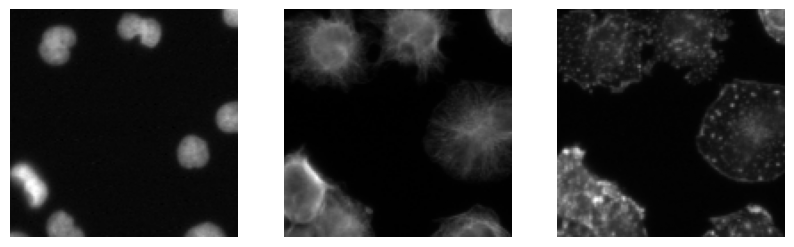

In [25]:
fig, axes = plt.subplots(1,3, figsize=(10,4))

for i in range(3):
    axes[i].imshow(sample[i], cmap="gray")
    axes[i].axis("off")

plt.show()

Saving x and y arrays for further computation

In [26]:
X = []
y = []

In [28]:
for _, row in tqdm(metadata_with_moa.iterrows(), total=len(metadata_with_moa)):

    # Load image
    img = preprocess_image(row)

    #if shapes are different first time
    if img is None:
      continue

    X.append(img)
    # store moa + compound
    y.append([row["moa"], row["compound"], row["concentration"]])

100%|██████████| 3848/3848 [2:01:11<00:00,  1.89s/it]


In [29]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3845, 3, 128, 128)
y shape: (3845, 3)


In [30]:
np.save("data/splits/X_images.npy", X)
np.save("data/splits/y_labels.npy", y)

print("Saved processed dataset.")

Saved processed dataset.


In [31]:
#sanity check
X = np.load("data/splits/X_images.npy")
y = np.load("data/splits/y_labels.npy")

print(X.shape)

(3845, 3, 128, 128)


In [32]:
print("y shape:", y.shape)

y shape: (3845, 3)
